# 2 - Face Mask Detection - Computer Vision

<img src='https://smartclick.ai/wp-content/uploads/2022/04/Mask-Detection-1.png'>

Bu çalışmada yüz görsellerinde maske olup olmadığını tahmin eden bir computer vision modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. CNN modeli kurma
6. Modeli eğitme
7. Modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen maske datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Face Mask Detection Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config',
 'without mask',
 'target.npy',
 'data.npy',
 'drive',
 'with mask',
 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde npy dosyalarını okuyup veri setinin boyutunu inceleyeceğim.

In [6]:
x = np.load('/content/data.npy')
y = np.load('/content/target.npy')

x.shape, y.shape

((1372, 100, 100, 1), (1372, 2))

In [7]:
np.unique(y, return_counts=True)

(array([0., 1.], dtype=float32), array([1372, 1372]))

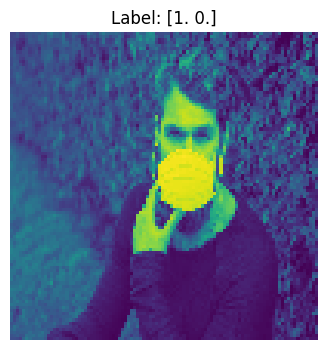

In [8]:
plt.figure(figsize=(4,4))
plt.imshow(x[0])
plt.title(f'Label: {y[0]}')
plt.axis('off')
plt.show()

## 3. Veri Temizleme

In [9]:
# Bu bölümde görüntüleri normalize edeceğim ve etiketleri düzenleyeceğim.

In [10]:
x = x.astype('float32') / 255.0

if len(y.shape) > 1:
    y = y.flatten()

y = y.astype('int32')
x.shape, y.shape

((1372, 100, 100, 1), (2744,))

## 4. Feature Engineering

In [11]:
# Bu bölümde veriyi eğitim ve test olarak ayıracağım ve etiketleri one-hot hale getireceğim.

In [12]:
if y.shape == (2744,):
    # Reshape y back to (num_samples, num_classes) assuming it was originally one-hot encoded
    y = y.reshape(-1, 2)
    # Convert one-hot encoded labels to single integer labels
    y = np.argmax(y, axis=1)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)

x_train.shape, x_test.shape

((1097, 100, 100, 1), (275, 100, 100, 1))

## 5. CNN Modeli Kurma

In [13]:
# Bu bölümde maskeli ve maskesiz yüzleri ayırmak için bir CNN modeli kuracağım.

In [14]:
input_shape = x_train.shape[1:]

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,352,770 (16.60 MB)

 Trainable params: 4,352,770 (16.60 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Modeli Eğitme

In [15]:
# Bu bölümde CNN modelini eğitim verisi ile eğiteceğim.

In [16]:
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 469ms/step - accuracy: 0.5025 - loss: 0.6935 - val_accuracy: 0.4818 - val_loss: 0.6930
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 467ms/step - accuracy: 0.5025 - loss: 0.6922 - val_accuracy: 0.4818 - val_loss: 0.6912
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 456ms/step - accuracy: 0.5745 - loss: 0.6861 - val_accuracy: 0.6909 - val_loss: 0.6756
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 435ms/step - accuracy: 0.6798 - loss: 0.6491 - val_accuracy: 0.7273 - val_loss: 0.6067
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 414ms/step - accuracy: 0.7538 - loss: 0.5541 - val_accuracy: 0.7909 - val_loss: 0.4808
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 482ms/step - accuracy: 0.8349 - loss: 0.4514 - val_accuracy: 0.8364 - val_loss: 0.3979
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 444ms/step - accuracy: 0.8592 - loss: 0.3623 - val_accuracy: 0.9000 - val_loss: 0.3195
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 450ms/step - accuracy: 0.8865 - loss: 0.3087 - val_accu

## 7. Modeli Değerlendirme

In [17]:
# Bu bölümde modeli test verisi üzerinde değerlendirip accuracy sonucuna bakacağım.

In [18]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test Accuracy:', test_accuracy)
print('Test Loss:', test_loss)

Test Accuracy: 0.9272727370262146
Test Loss: 0.22498220205307007


In [19]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       138
           1       0.90      0.96      0.93       137

    accuracy                           0.93       275
   macro avg       0.93      0.93      0.93       275
weighted avg       0.93      0.93      0.93       275



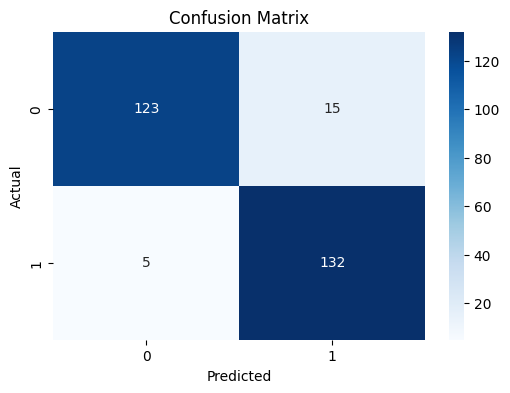

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [21]:
# Bu bölümde test setinden bir yüz görseli için maske tahmini yapacağım.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


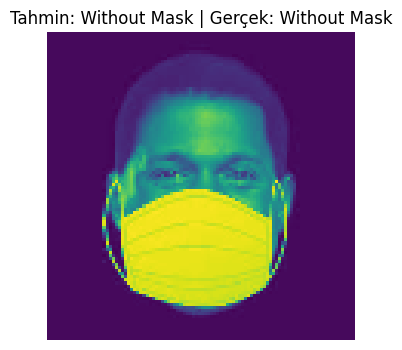

In [22]:
sample_index = 0
sample_image = x_test[sample_index]
sample_prediction = np.argmax(model.predict(sample_image.reshape(1, *sample_image.shape)), axis=1)[0]

label_map = {0: 'Without Mask', 1: 'With Mask'}

plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title(f"Tahmin: {label_map[sample_prediction]} | Gerçek: {label_map[y_test[sample_index]]}")
plt.axis('off')
plt.show()

## 9. Sonuç

Bu projede yüz görsellerinde maske olup olmadığını tahmin etmek için CNN tabanlı bir computer vision modeli kullanıldı. Elde edilen sonuçlara göre model 0.9273 accuracy değeri elde etti.